## **DATA PREPARATION & CLEANING** 

In [2]:
# Import the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import the dataset 
listings = pd.read_csv(r'/Users/diyagajjar/Desktop/INM433 Visual Analytics /CW2/listings.csv')
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,4.93,4.60,4.65,NaN,f,1,1,0,0,0.53
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,4.46,4.85,4.54,NaN,t,2,2,0,0,0.09


In [4]:
# Keep only the relevant variables
cols_to_keep = ['id', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type', 'accommodates', 
                'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
                'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count', 'reviews_per_month']

# Drop the irrelevant variables 
    # Create a new dataframe with only the list of variables above
Listings = listings[cols_to_keep].copy()

# Drop the duplicates 
    # Remove duplicates based on ID (keeping the last/newest one)
Listings.drop_duplicates(subset=['id'], keep='last', inplace=True)

In [5]:
# CLEAN PRICE
# Remove '$' and ',' symbols and convert to numbers
Listings['price'] = Listings['price'].replace(r'[$,]', '', regex=True).astype(float)

# Remove rows with Price = 0
ListingsListingsListings = Listings[Listings['price'] > 0]

# CLEAN BATHROOMS
# Fill missing 'bathrooms' by extracting the number from 'bathrooms_text'
# (The regex r'(\d+\.?\d*)' finds numbers like '1' or '1.5')
Listings['bathrooms'] = Listings['bathrooms'].fillna(
    Listings['bathrooms_text'].str.extract(r'(\d+\.?\d*)', expand=False).astype(float))

# Drop the old text column
Listings.drop(columns=['bathrooms_text'], inplace=True)

# Check the result
print(Listings[['price', 'bathrooms']].head())

   price  bathrooms
0   70.0        1.0
1  149.0        1.0
2  411.0        2.0
3    NaN        1.5
4  210.0        1.0


In [6]:
# CHECK EVERYTHING (See where the gaps are)
print("Missing values before cleaning:")
print(Listings.isnull().sum())

# APPLY SPECIFIC RULES (The "Logic" Fixes)
# Logic: If reviews_per_month is missing, it just means 0 reviews. Don't drop it.
Listings['reviews_per_month'] = Listings['reviews_per_month'].fillna(0)

# THE "CATCH-ALL" DROP (The Safety Net)
# Logic: For ANY other variable (Price, Bedrooms, Lat/Lon, etc.), if data is missing, the row is broken. Drop it.
Listings.dropna(inplace=True)

# VERIFY THE RESULT
print("\nMissing values after cleaning:")
print(Listings.isnull().sum()) # Should be all zeros now
print(f"\nFinal Shape: {Listings.shape}")

Missing values before cleaning:
id                                    0
neighbourhood_cleansed                0
latitude                              0
longitude                             0
room_type                             0
accommodates                          0
bathrooms                           361
bedrooms                          12775
beds                              34920
price                             34908
minimum_nights                        0
availability_365                      0
number_of_reviews                     0
review_scores_rating              24122
calculated_host_listings_count        0
reviews_per_month                 24122
dtype: int64

Missing values after cleaning:
id                                0
neighbourhood_cleansed            0
latitude                          0
longitude                         0
room_type                         0
accommodates                      0
bathrooms                         0
bedrooms                       

In [7]:
# FEATURE ENGINEERING (Prepare the variables)

# Calculate Distance to Centre (Trafalgar Square) in KM
# Use your simplified Euclidean formula, which converts degrees to km
# (Latitude * 111km, Longitude * 69km)
center_lat = 51.5074
center_lon = -0.1278

Listings['Distance_to_Center'] = np.sqrt(
    ((Listings['latitude'] - center_lat) * 111) ** 2 + 
    ((Listings['longitude'] - center_lon) * 69) ** 2
)
print("✔ Created 'Distance_to_Center' (in km)")

# Create Log Price (for Modelling & EDA)
# Log-transform the price because it is highly skewed
Listings['Log_Price'] = np.log1p(Listings['price'])
print("✔ Created 'Log_Price'")

✔ Created 'Distance_to_Center' (in km)
✔ Created 'Log_Price'


In [8]:
# Print data summary (check for no missing values)
print(Listings.info())

# Check the new calculated variables to ensure they look right
print(Listings[['id', 'price', 'Distance_to_Center']].head())

# Save the clean data to a CSV file (exclude index numbers)
Listings.to_csv('AirBnB_Listings_Ldn.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 47903 entries, 0 to 96867
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              47903 non-null  int64  
 1   neighbourhood_cleansed          47903 non-null  object 
 2   latitude                        47903 non-null  float64
 3   longitude                       47903 non-null  float64
 4   room_type                       47903 non-null  object 
 5   accommodates                    47903 non-null  int64  
 6   bathrooms                       47903 non-null  float64
 7   bedrooms                        47903 non-null  float64
 8   beds                            47903 non-null  float64
 9   price                           47903 non-null  float64
 10  minimum_nights                  47903 non-null  int64  
 11  availability_365                47903 non-null  int64  
 12  number_of_reviews               47903

# **EXPLORATORY DATA ANALYSIS (EDA)**

In [10]:
from IPython.display import display

# This forces Python to render it as a nice HTML table
display(Listings.describe().round(2))
print(Listings.info()) # Checks for nulls/data types

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,calculated_host_listings_count,reviews_per_month,Distance_to_Center,Log_Price
count,4.790300e+04,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00,47903.00
mean,8.052458e+17,51.51,-0.13,3.53,1.34,1.53,1.96,192.88,4.32,203.28,34.78,4.67,16.44,1.28,7.39,4.88
std,5.502700e+17,0.05,0.10,2.17,0.66,0.96,1.38,862.45,16.03,120.28,64.15,0.51,40.79,1.42,4.90,0.75
min,1.391300e+04,51.30,-0.50,1.00,0.00,0.00,0.00,10.00,1.00,0.00,1.00,1.00,1.00,0.01,0.01,2.40
25%,5.049041e+07,51.49,-0.19,2.00,1.00,1.00,1.00,76.00,1.00,88.00,4.00,4.57,1.00,0.33,3.86,4.34
50%,9.694236e+17,51.51,-0.13,3.00,1.00,1.00,2.00,131.00,2.00,221.00,13.00,4.82,3.00,0.83,6.01,4.88
75%,1.280487e+18,51.54,-0.07,4.00,1.50,2.00,2.00,210.00,3.00,320.00,37.00,5.00,13.00,1.72,10.00,5.35
max,1.508900e+18,51.68,0.28,16.00,12.50,15.00,24.00,74100.00,999.00,365.00,1902.00,5.00,500.00,36.96,28.85,11.21


<class 'pandas.core.frame.DataFrame'>
Index: 47903 entries, 0 to 96867
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              47903 non-null  int64  
 1   neighbourhood_cleansed          47903 non-null  object 
 2   latitude                        47903 non-null  float64
 3   longitude                       47903 non-null  float64
 4   room_type                       47903 non-null  object 
 5   accommodates                    47903 non-null  int64  
 6   bathrooms                       47903 non-null  float64
 7   bedrooms                        47903 non-null  float64
 8   beds                            47903 non-null  float64
 9   price                           47903 non-null  float64
 10  minimum_nights                  47903 non-null  int64  
 11  availability_365                47903 non-null  int64  
 12  number_of_reviews               47903

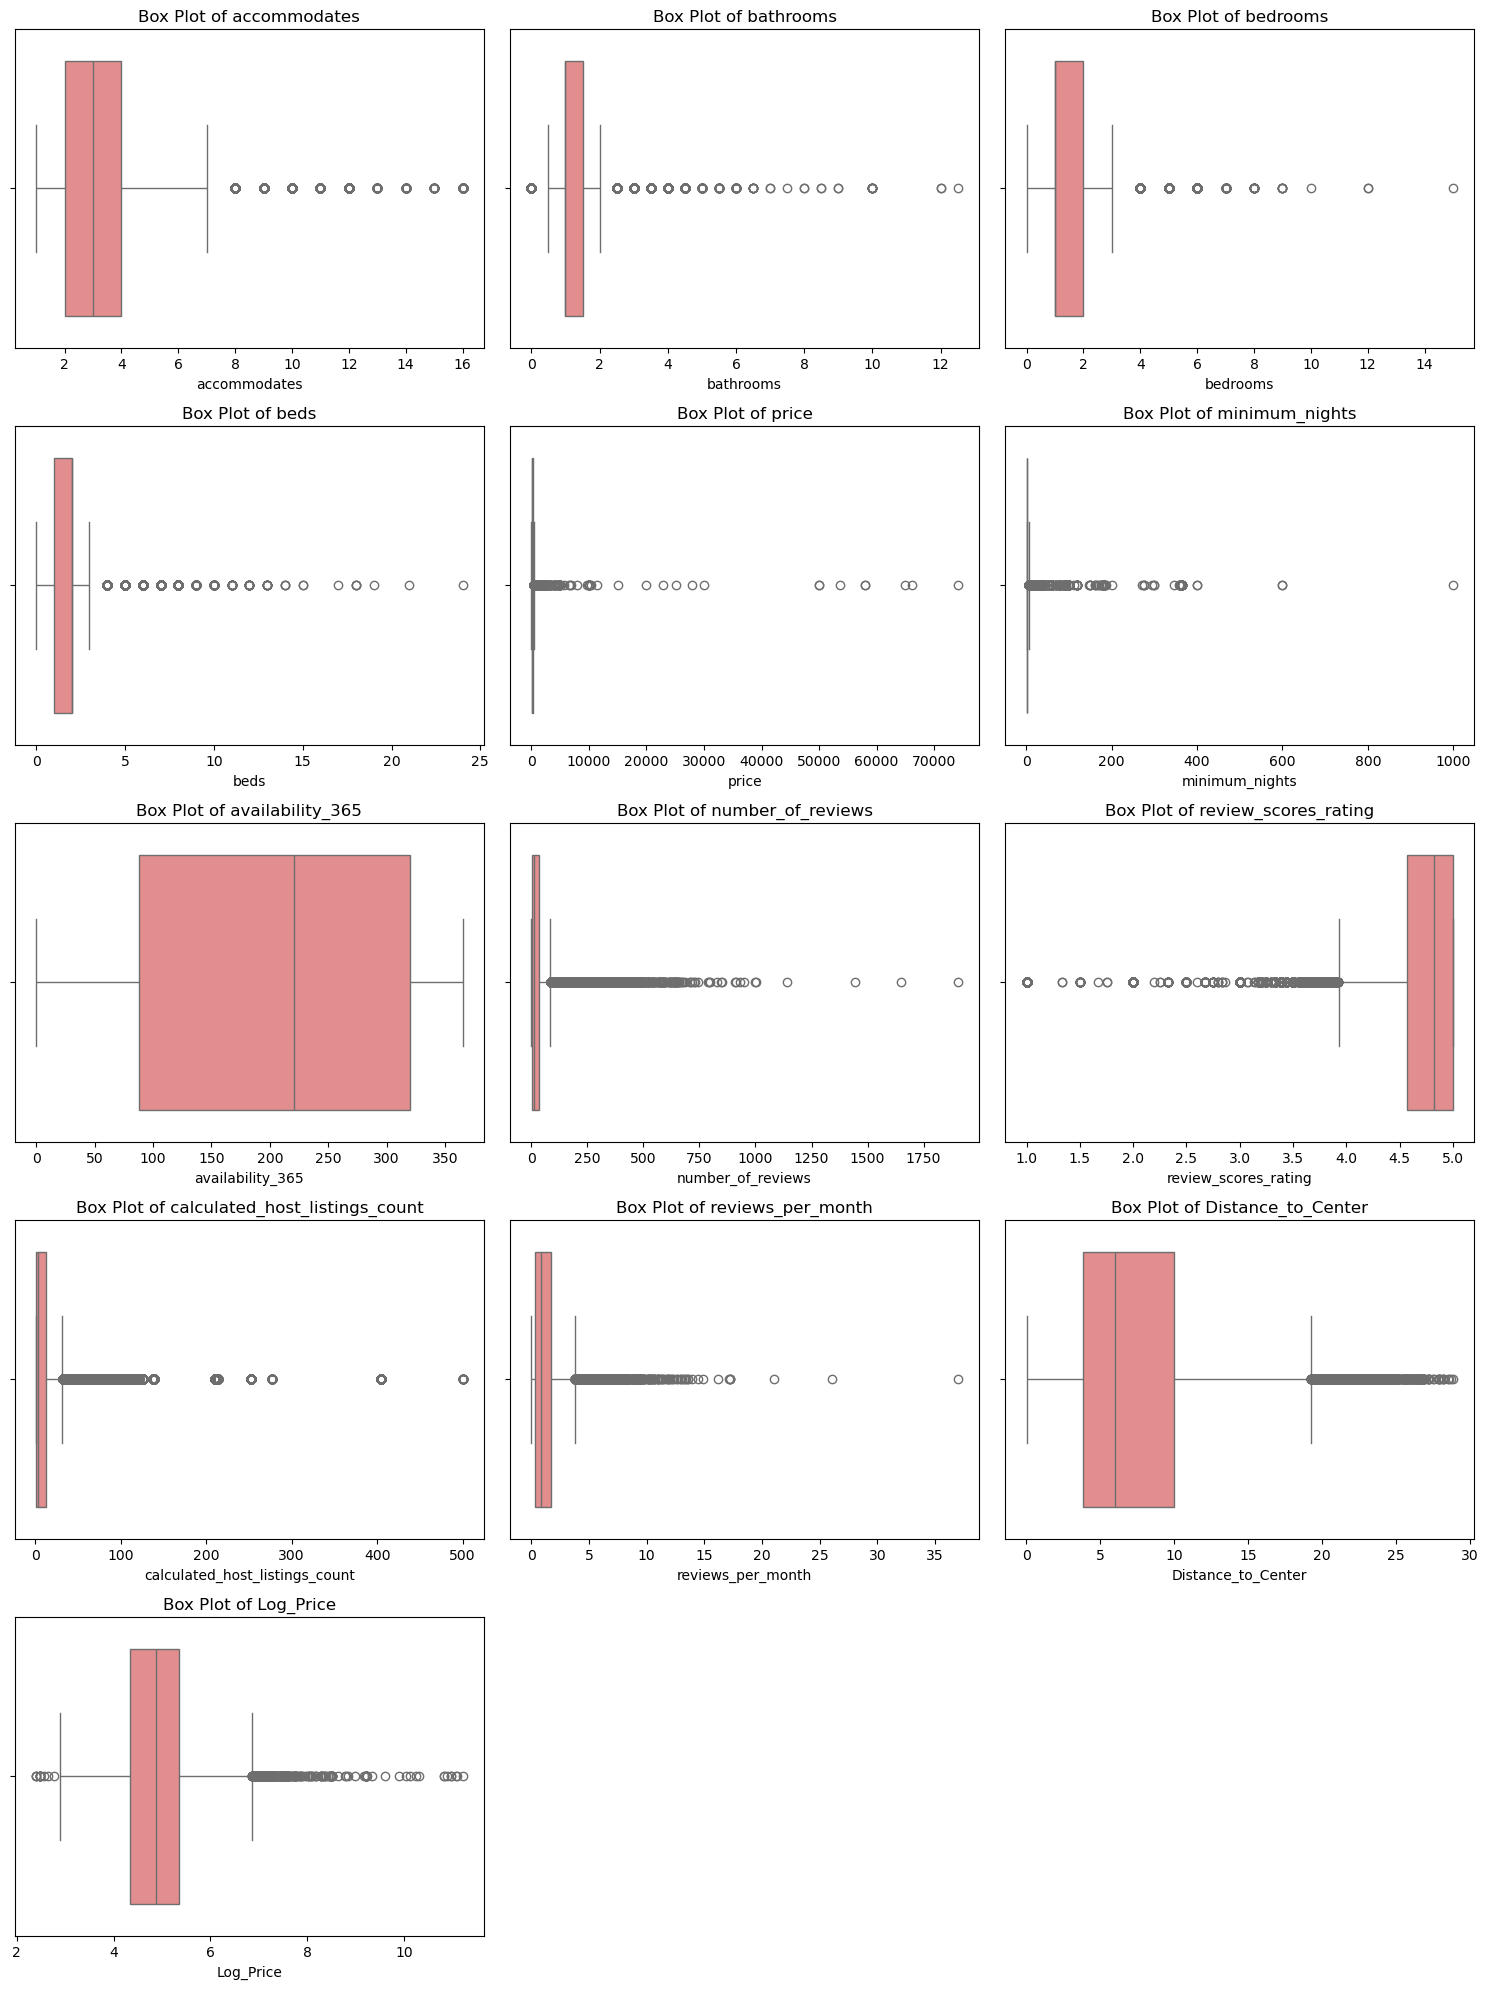

In [11]:
# Setup Data: Select numbers and drop unwanted columns
numerical_data = Listings.select_dtypes(include=['number'])
cols_to_drop = ['id', 'latitude', 'longitude', 'scrape_id', 'host_id']
plot_data = numerical_data.drop(columns=cols_to_drop, errors='ignore')

# Setup Grid
num_cols = len(plot_data.columns)
rows = (num_cols // 3) + 1
plt.figure(figsize=(15, rows * 4))

# Loop and Plot
for i, col in enumerate(plot_data.columns):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(x=plot_data[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [12]:
# CHECK: Look at the suspicious rows before deleting
print("--- Check Suspicious Minimum Nights ---")
long_stays = Listings[Listings['minimum_nights'] > 365]
print(f"Found {len(long_stays)} listings requiring > 365 nights.")
print(long_stays[['id', 'minimum_nights', 'price']].head())

# ACTION: Filter them out
# We keep only listings with minimum_nights < 365
Listings = Listings[Listings['minimum_nights'] < 365]

# VERIFY: Confirm the max is now normal
print("\nNew Max Minimum Nights:", Listings['minimum_nights'].max())

--- Check Suspicious Minimum Nights ---
Found 5 listings requiring > 365 nights.
                        id  minimum_nights  price
4150               6603139             600   59.0
4296               6760084             600   72.0
6347               9101592             400   80.0
20708             25028136             400  952.0
63320  1117354642808991236             999  322.0

New Max Minimum Nights: 364


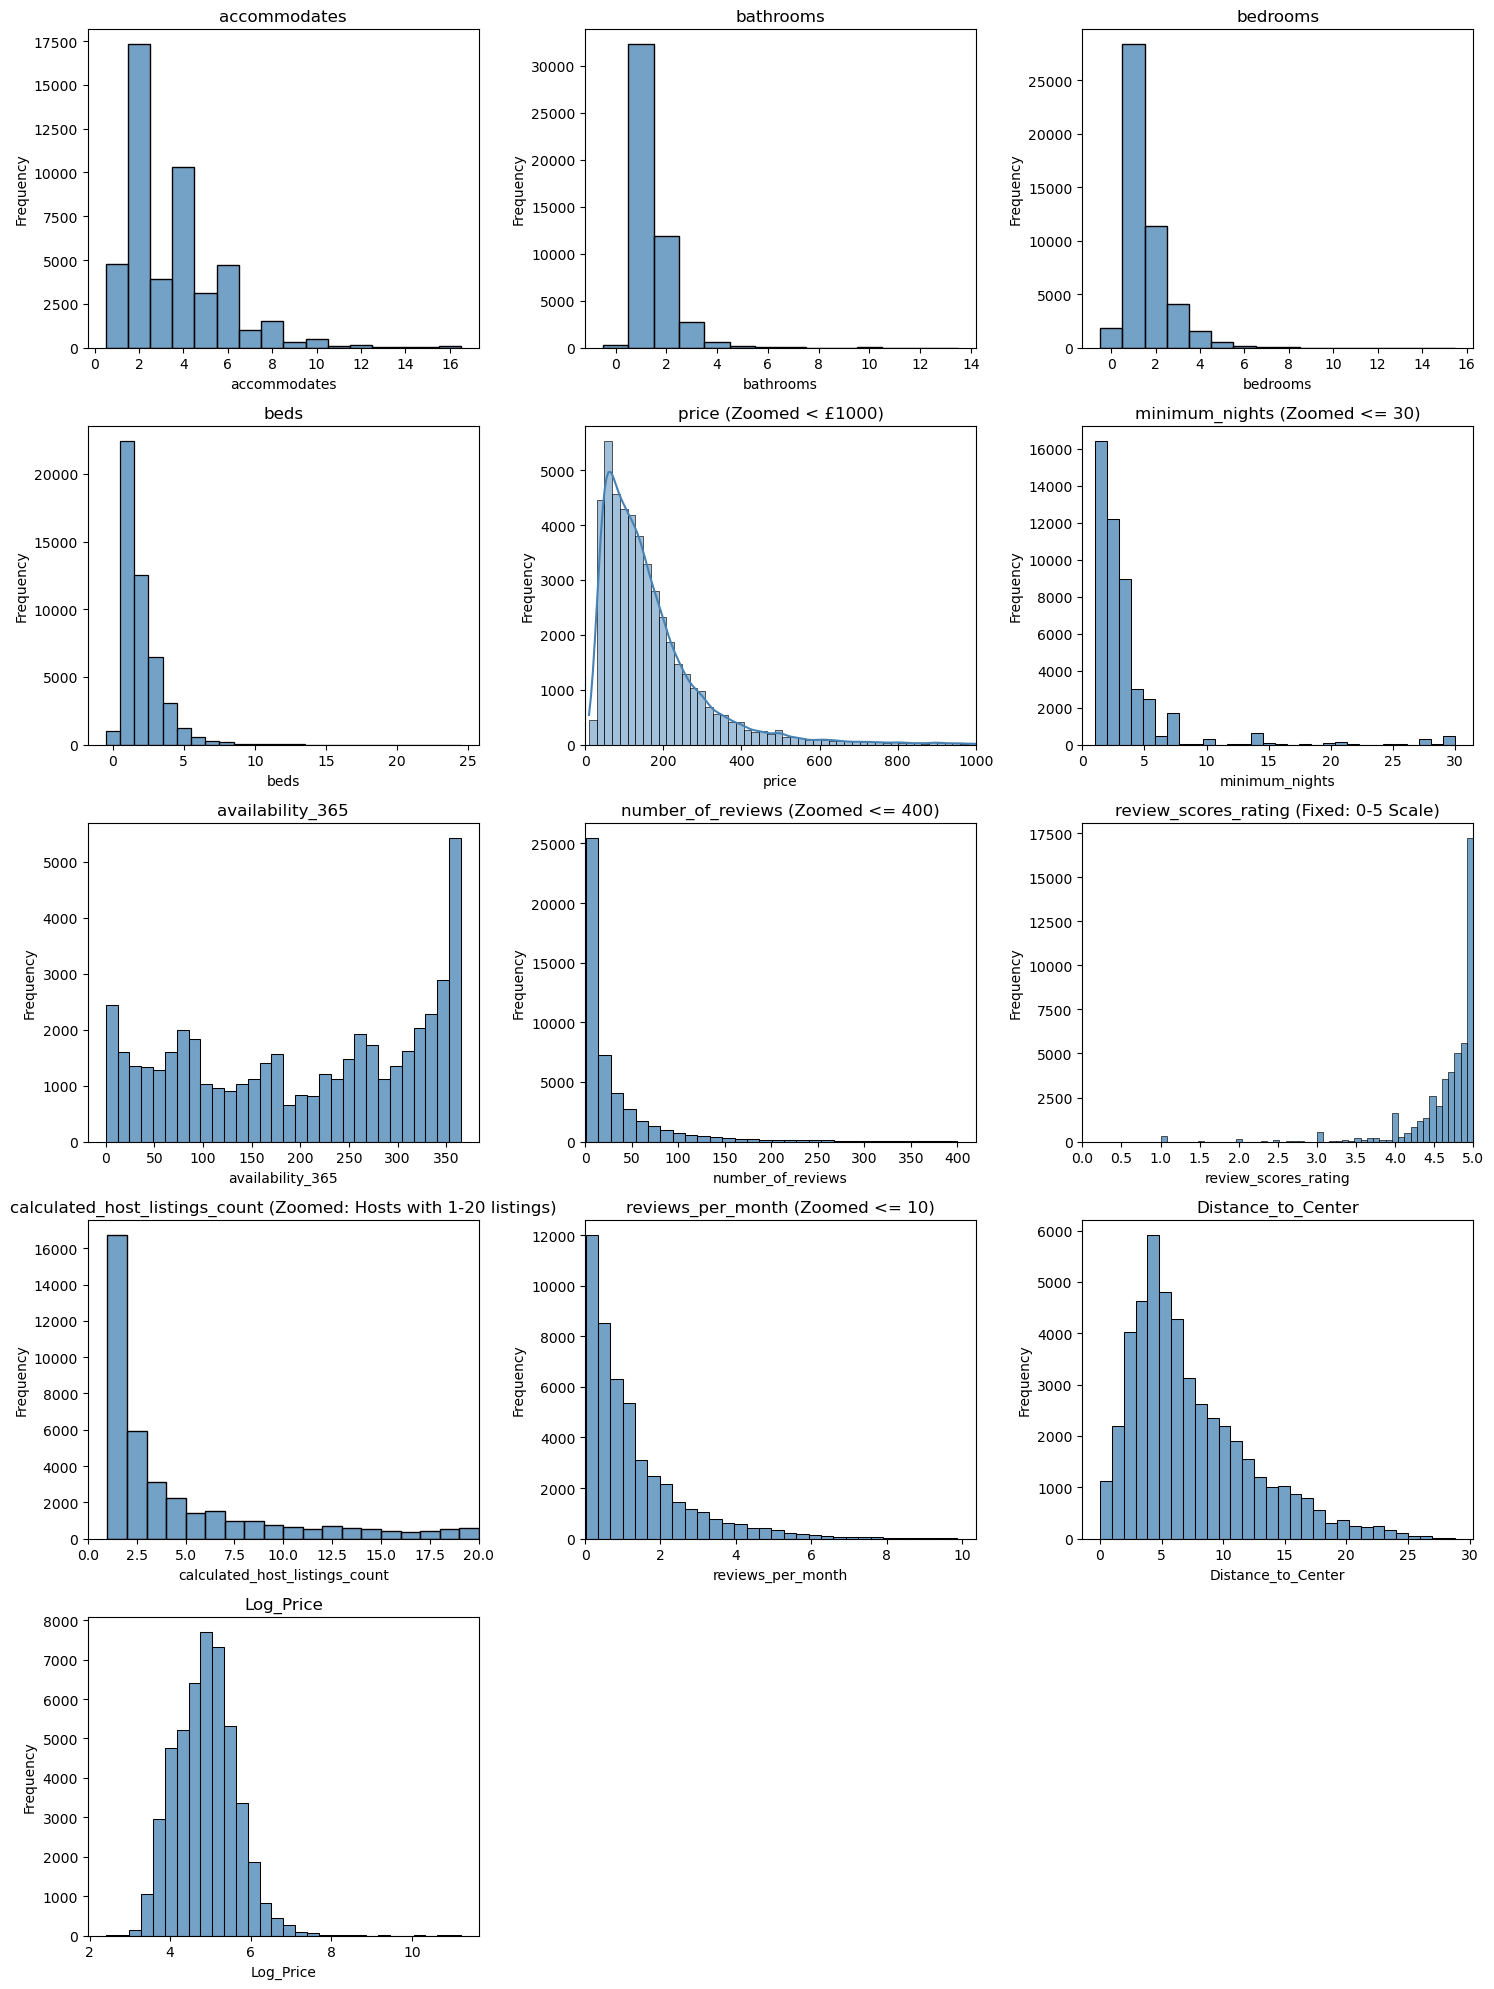

In [13]:
# Setup Data (Refresh data after cleaning)
numerical_data = Listings.select_dtypes(include=['number'])
cols_to_drop = ['id', 'latitude', 'longitude', 'scrape_id', 'host_id']
plot_data = numerical_data.drop(columns=cols_to_drop, errors='ignore')

# Setup Grid
num_cols = len(plot_data.columns)
rows = (num_cols // 3) + 1
plt.figure(figsize=(15, rows * 4))

# Loop and Plot
for i, col in enumerate(plot_data.columns):
    plt.subplot(rows, 3, i + 1)
    
    # REVIEW SCORES: Fine Detail (0.0 to 5.0)
    if col == 'review_scores_rating':
        sns.histplot(plot_data[col], bins=50, kde=False, color='steelblue')
        plt.xlim(0, 5)
        plt.xticks(np.arange(0, 5.5, 0.5)) # Labels: 0.0, 0.5, 1.0...
        plt.title(f'{col} (Fixed: 0-5 Scale)')

    # HOST LISTINGS: 1 Bin per Number (Zoomed) 
    elif col == 'calculated_host_listings_count':
        # Zoom to 20, but ensure 1 bar = 1 listing count
        sns.histplot(plot_data[plot_data[col] <= 20][col], binwidth=1, kde=False, color='steelblue')
        plt.xlim(0, 20)
        plt.title(f'{col} (Zoomed: Hosts with 1-20 listings)')

    # PRICE: Zoomed < 1000 
    elif col == 'price':
        sns.histplot(Listings[Listings['price'] < 1000]['price'], bins=50, kde=True, color='steelblue')
        plt.xlim(0, 1000)
        plt.title(f'{col} (Zoomed < £1000)')

    # DEFAULTS for everything else 
    else:
        is_discrete = col in ['bedrooms', 'beds', 'bathrooms', 'accommodates']
        
        # Apply Zoom limits for other variables just for the plot
        data_to_plot = plot_data[col]
        limit_map = {'minimum_nights': 30, 'number_of_reviews': 400, 'reviews_per_month': 10}
        
        if col in limit_map:
            data_to_plot = data_to_plot[data_to_plot <= limit_map[col]]
            plt.title(f'{col} (Zoomed <= {limit_map[col]})')
        else:
            plt.title(col)

        sns.histplot(data_to_plot, bins=30, discrete=is_discrete, kde=False, color='steelblue')
        
        if col in ['minimum_nights', 'number_of_reviews', 'reviews_per_month']:
            plt.xlim(left=0)

    plt.ylabel('Frequency')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

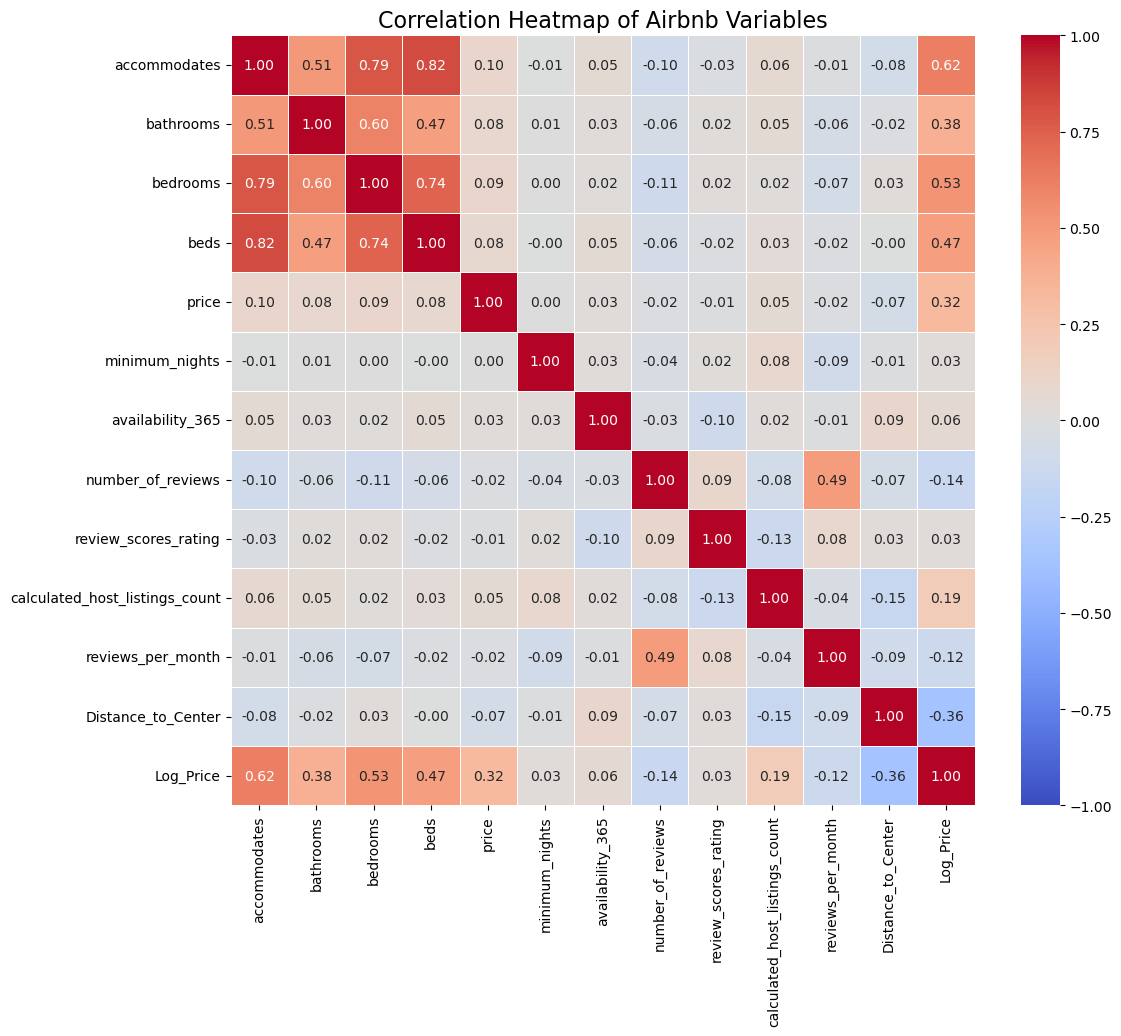

In [14]:
# Clean Data for Correlation 
# Remove the IDs and Coordinates as they don't have meaningful correlations
corr_data = Listings.select_dtypes(include=['number']).drop(
    columns=['id', 'latitude', 'longitude', 'scrape_id', 'host_id'], 
    errors='ignore'
)

# Calculate & Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_data.corr(), 
            annot=True,        # Show the actual numbers
            fmt=".2f",         # Round to 2 decimal places
            cmap='coolwarm',   # Red = Positive Link, Blue = Negative Link
            vmin=-1, vmax=1,   # Fix the scale from -1 to +1
            linewidths=0.5)

plt.title('Correlation Heatmap of Airbnb Variables', fontsize=16)
plt.savefig('CorrelationHeatmap.png', dpi=300, bbox_inches='tight')
plt.show()

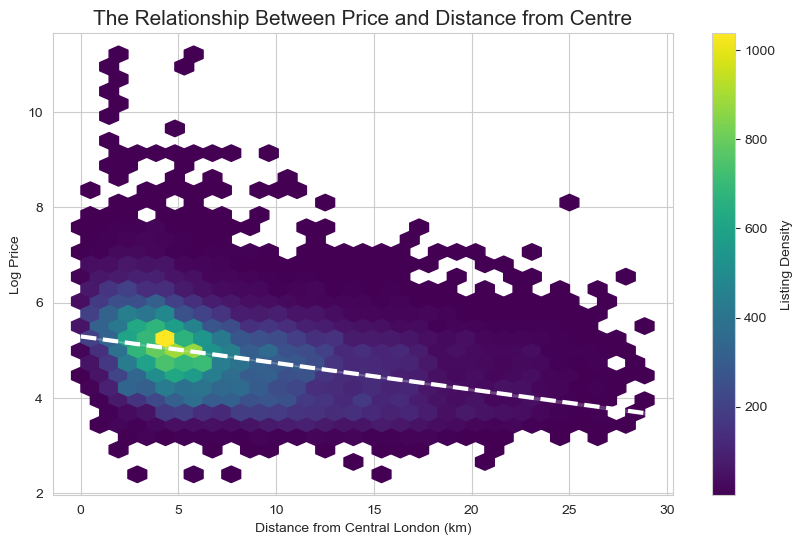

In [15]:
# Set style
sns.set_style("whitegrid")

# Create Figure
plt.figure(figsize=(10, 6))

# Plot Hexbin using your existing 'distance_to_center' (km) and 'Log_Price'
hb = plt.hexbin(Listings['Distance_to_Center'], Listings['Log_Price'], 
                gridsize=30, cmap='viridis', mincnt=1)

# Add Trend Line to show the drop clearly
sns.regplot(x=Listings['Distance_to_Center'], y=Listings['Log_Price'], 
            scatter=False, color='white', line_kws={"linewidth": 3, "linestyle": "--"})

# Formatting
plt.colorbar(hb, label='Listing Density')
plt.title("The Relationship Between Price and Distance from Centre", fontsize=15)
plt.xlabel("Distance from Central London (km)")
plt.ylabel("Log Price")

# Save and Show
plt.savefig('Figure_EDA_Hexbin.png', dpi=300, bbox_inches='tight')
plt.show()

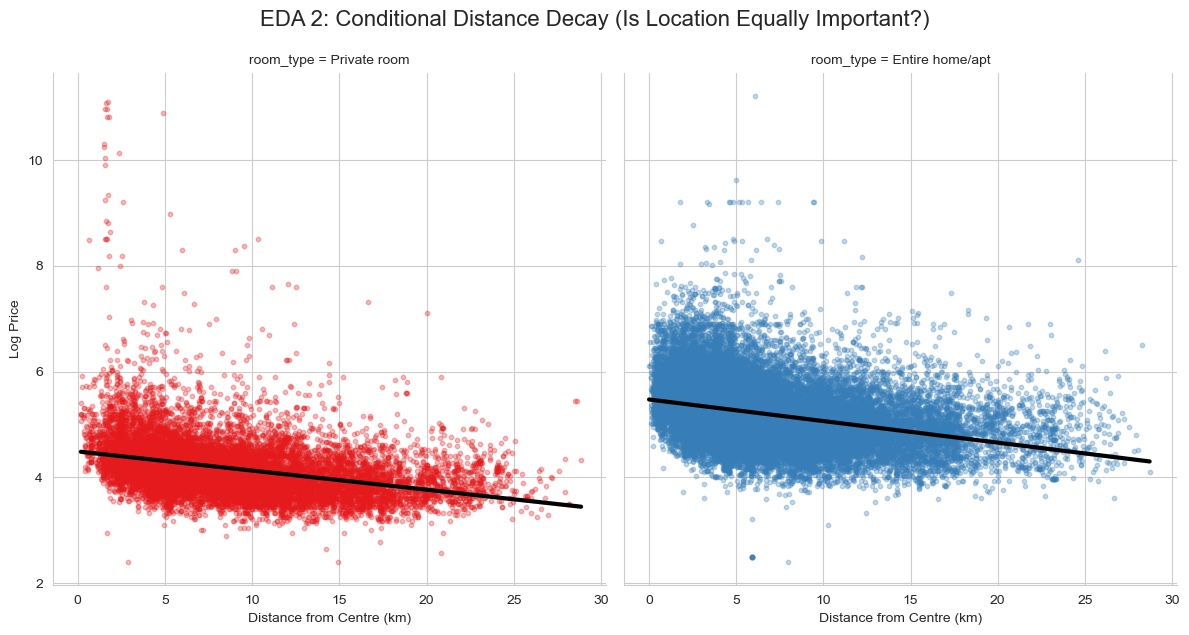

In [16]:
# Filter to main room types
facet_data = Listings[Listings['room_type'].isin(['Entire home/apt', 'Private room'])]

# Create FacetGrid (Conditional Scatter)
g = sns.lmplot(
    data=facet_data,
    x="Distance_to_Center",
    y="Log_Price",
    col="room_type",    # <--- This creates the separate side-by-side graphs
    hue="room_type",
    palette="Set1",
    height=6,
    aspect=1,
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'linewidth': 3, 'color': 'black'}
)

# Formatting
g.set_axis_labels("Distance from Centre (km)", "Log Price")
g.fig.suptitle("EDA 2: Conditional Distance Decay (Is Location Equally Important?)", y=1.05, fontsize=16)

plt.savefig('Figure_EDA_Facets.png', dpi=300, bbox_inches='tight')
plt.show()

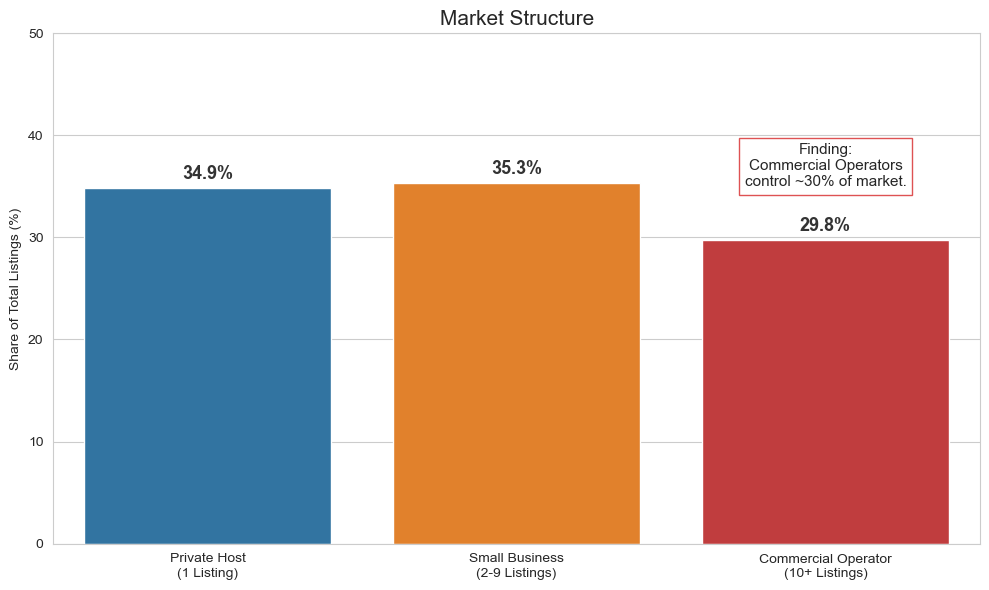

In [17]:
sns.set_style("whitegrid")

# Data prep
def categorize_host(n):
    if n == 1:
        return 'Private Host\n(1 Listing)'
    elif n < 10:
        return 'Small Business\n(2-9 Listings)'
    else:
        return 'Commercial Operator\n(10+ Listings)'

# Apply category
Listings['Host_Type'] = Listings['calculated_host_listings_count'].apply(categorize_host)

# Calculate proportions
market_share = Listings['Host_Type'].value_counts(normalize=True).reset_index()
market_share.columns = ['Host_Type', 'Percentage']
market_share['Percentage'] = market_share['Percentage'] * 100

# Sort logically
order = ['Private Host\n(1 Listing)', 'Small Business\n(2-9 Listings)', 'Commercial Operator\n(10+ Listings)']
market_share['Host_Type'] = pd.Categorical(market_share['Host_Type'], categories=order, ordered=True)
market_share = market_share.sort_values('Host_Type')
 
plt.figure(figsize=(10, 6))

# Define Colours
colors = {'Private Host\n(1 Listing)': '#1f77b4', 
          'Small Business\n(2-9 Listings)': '#ff7f0e', 
          'Commercial Operator\n(10+ Listings)': '#d62728'}

# Plot the graph
ax = sns.barplot(
    data=market_share, 
    x='Host_Type', 
    y='Percentage', 
    hue='Host_Type', 
    palette=colors, 
    legend=False
)

# Formatting the graphs
plt.title("Market Structure", fontsize=15)
plt.ylabel("Share of Total Listings (%)")
plt.xlabel(None) # Remove X label as the ticks are self-explanatory
plt.ylim(0, 50)  # Give some headroom for text

# Add Labels on Top of Bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=13, fontweight='bold', color='#333333')

# Add "Insight" Annotation
plt.text(2, 35, "Finding:\nCommercial Operators\ncontrol ~30% of market.", 
         ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='#d62728'), fontsize=11)

plt.tight_layout()
plt.savefig('Figure_EDA_Structure_Bar_Final.png', dpi=300)
plt.show()

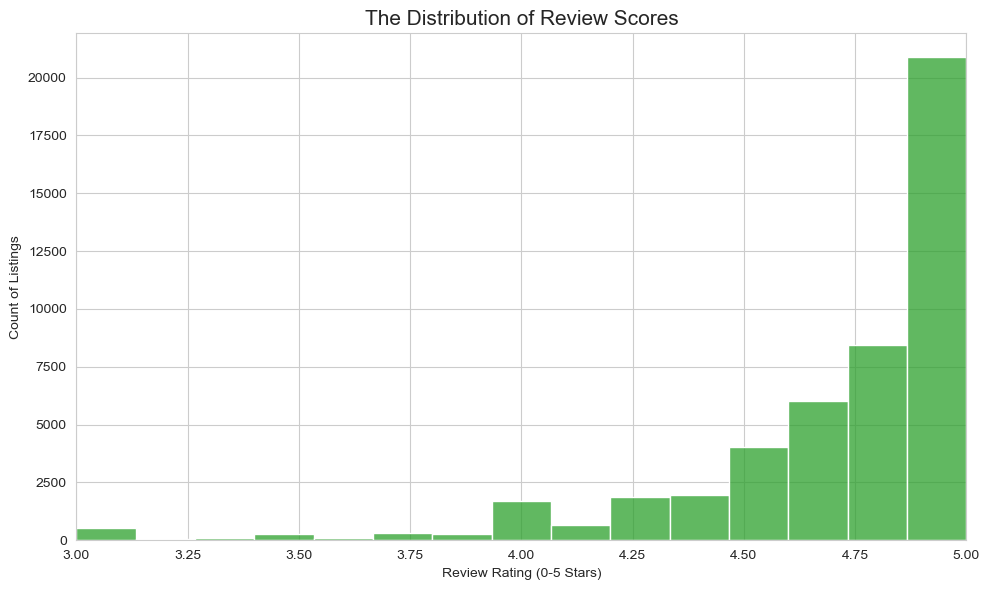

In [18]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Filter to remove zero-review listings so the graph isn't messy
review_data = Listings[Listings['number_of_reviews'] > 0]

# PLOT: Histogram of Rating Scores
sns.histplot(review_data['review_scores_rating'], bins=30, color='#2ca02c', kde=False)

# FORMATTING
plt.title("The Distribution of Review Scores", fontsize=15)
plt.xlabel("Review Rating (0-5 Stars)")
plt.ylabel("Count of Listings")
plt.xlim(3, 5) # Zoom in on the 3-5 star range where all the data is

plt.tight_layout()
plt.savefig('Figure_EDA_Reviews.png', dpi=300)
plt.show()

/var/folders/_j/fglspfs526g41dfhmwfs7hxw0000gn/T/ipykernel_7548/1669447003.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  price_grid = heatmap_data.pivot_table(index='Distance_Zone', columns='room_type', values='price', aggfunc='median')
/var/folders/_j/fglspfs526g41dfhmwfs7hxw0000gn/T/ipykernel_7548/1669447003.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  volume_grid = heatmap_data.pivot_table(index='Distance_Zone', columns='room_type', values='id', aggfunc='count')


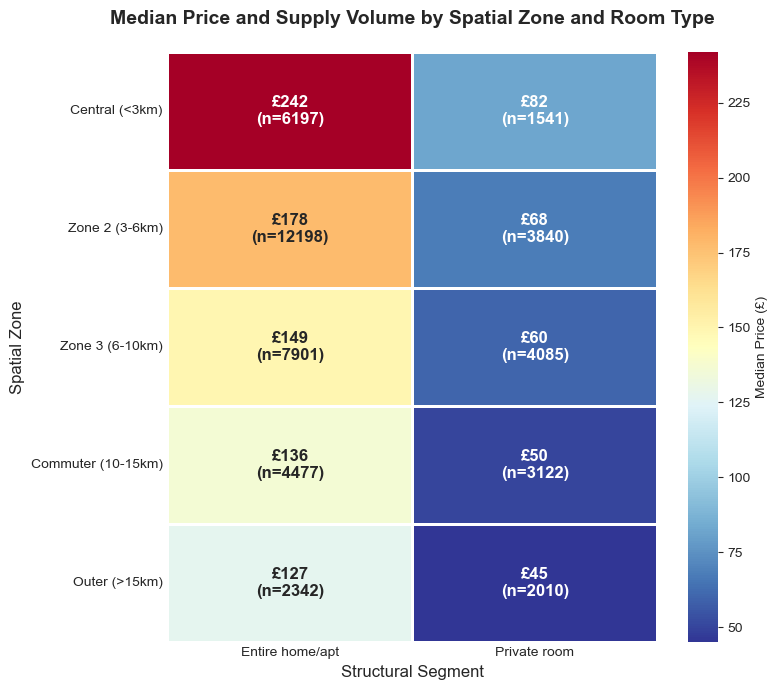

In [19]:
sns.set_style("white")

# Prepare the data 
bins = [0, 3, 6, 10, 15, 30]
labels = ['Central (<3km)', 'Zone 2 (3-6km)', 'Zone 3 (6-10km)', 'Commuter (10-15km)', 'Outer (>15km)']
Listings['Distance_Zone'] = pd.cut(Listings['Distance_to_Center'], bins=bins, labels=labels)

# Filter for MAIN room types only (Drop "Shared room" to remove the tiny empty column)
heatmap_data = Listings[Listings['room_type'].isin(['Entire home/apt', 'Private room'])]

# Create pivot tables
# We need TWO tables: one for Color (Price), one for Text (Volume)
price_grid = heatmap_data.pivot_table(index='Distance_Zone', columns='room_type', values='price', aggfunc='median')
volume_grid = heatmap_data.pivot_table(index='Distance_Zone', columns='room_type', values='id', aggfunc='count')

# Create custom annotations
# We combine Price and Volume into a single string for each cell
# e.g., "£150\n(n=2,000)"
labels = (np.asarray(["£{0:.0f}\n(n={1:.0f})".format(price, vol) 
                      for price, vol in zip(price_grid.values.flatten(), volume_grid.values.flatten())])
         ).reshape(price_grid.shape)

# Plot the heatmap
plt.figure(figsize=(8, 7))

# Plot Heatmap based on PRICE
sns.heatmap(
    price_grid, 
    annot=labels,       # Use our custom "Price + Volume" labels
    fmt="",             # Tell Seaborn the labels are raw strings
    cmap="RdYlBu_r",    # Red = Expensive, Blue = Cheap
    linewidths=1, 
    linecolor='white',
    cbar_kws={'label': 'Median Price (£)'},
    annot_kws={"size": 12, "weight": "bold"} # Make text readable
)

# Formating 
plt.title("Median Price and Supply Volume by Spatial Zone and Room Type", fontsize=14, weight='bold', pad=20)
plt.ylabel("Spatial Zone", fontsize=12)
plt.xlabel("Structural Segment", fontsize=12)

# Remove the tick marks for a cleaner look
plt.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.savefig('Figure_EDA_Matrix_Heatmap.png', dpi=300)
plt.show()

# **METHODOLOGY & VISUAL ANALYTICS WORKFLOW**

**PHASE 1: STRUCTURAL DISCOVERY** 

In [22]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Select the specific variables from your methodology
features = [
    'calculated_host_listings_count', 
    'availability_365', 
    'reviews_per_month', 
    'minimum_nights', 
    'room_type' # This is text, we need to fix it
]

# Create a specific subset of data for this analysis
cluster_data = Listings[features].copy()

# Handle Missing Values (Crucial for algorithms)
# If reviews_per_month is empty, it implies 0 reviews.
cluster_data['reviews_per_month'] = cluster_data['reviews_per_month'].fillna(0)

# Encode 'room_type' (One-Hot Encoding)
# Turns "Entire home" into columns like: room_type_Entire home (1 or 0)
cluster_data_encoded = pd.get_dummies(cluster_data, columns=['room_type'], drop_first=False)

# Scale the Data (Normalisation)
# This forces all variables to have a mean of 0 and std dev of 1.
# Without this, 'availability_365' (big numbers) would dominate 'reviews' (small numbers).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data_encoded)

print("Data Prepared.")
print(f"Shape of X_scaled: {X_scaled.shape}")

Data Prepared.
Shape of X_scaled: (47888, 8)


Running t-SNE... please wait...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 47888 samples in 0.038s...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 47888 samples in 11.129s...
[t-SNE] Computed conditional probabilities for sample 1000 / 47888
[t-SNE] Computed conditional probabilities for sample 2000 / 47888
[t-SNE] Computed conditional probabilities for sample 3000 / 47888
[t-SNE] Computed conditional probabilities for sample 4000 / 47888
[t-SNE] Computed conditional probabilities for sample 5000 / 47888
[t-SNE] Computed conditional probabilities for sample 6000 / 47888
[t-SNE] Computed conditional probabilities for sample 7000 / 47888
[t-SNE] Computed conditional probabilities for sample 8000 / 47888
[t-SNE] Computed conditional probabilities for sample 9000 / 47888
[t-SNE] Computed conditional probabilities for sample 10000 / 47888
[t-SNE] Computed conditional probabilities for sample 11000 / 47888
[t-SNE] Computed conditional probabilities for sample 12000 / 47888
[t-SNE] Computed conditional probabilities for sample 13000 / 47888
[t-SNE] Computed conditional probabilities for sample 14000 / 4788

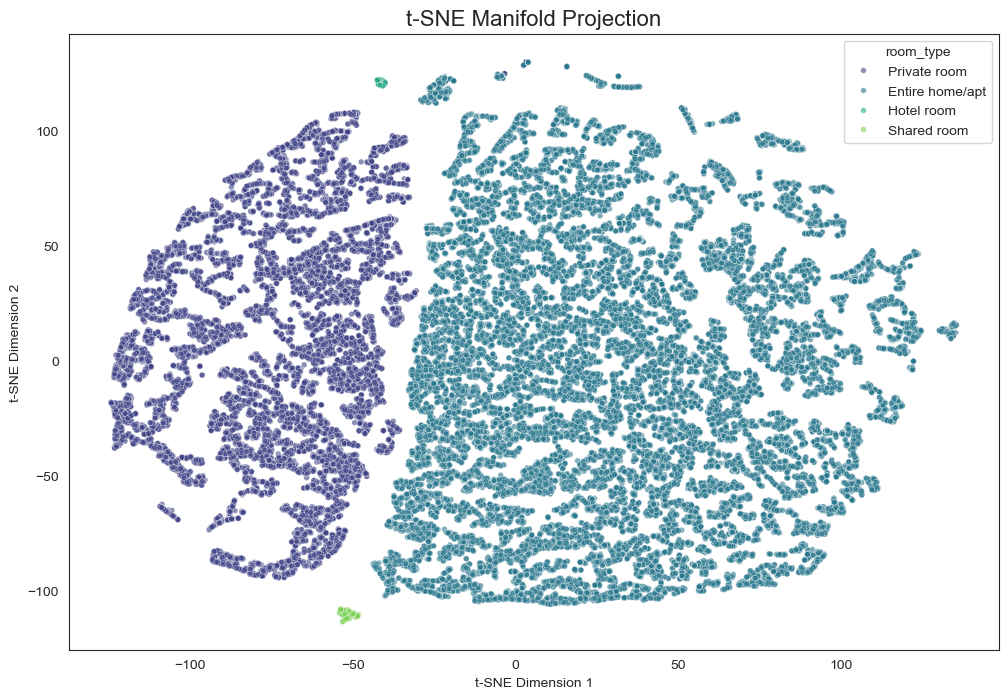

In [23]:
from sklearn.manifold import TSNE

# Initialise t-SNE (The dimensionality reduction engine)
# n_components=2: Squash data into 2 dimensions (X and Y)
# perplexity=30: Balances focus between local and global structure
# random_state=42: Ensures you get the same picture every time
tsne = TSNE(n_components=2, verbose=1, perplexity=30, n_iter=1000, random_state=42)

# Run the math (This might take 60 seconds)
print("Running t-SNE... please wait...")
tsne_results = tsne.fit_transform(X_scaled)

# Save the results back to your main dataframe
Listings['tsne_1'] = tsne_results[:,0]
Listings['tsne_2'] = tsne_results[:,1]

# Plot the "Islands"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='room_type',    # Colour points by room type to see separation
    palette='viridis',  # Pretty colors
    data=Listings,
    alpha=0.6,          # Transparency to handle overlapping dots
    s=17                # Dot size
)

plt.title('t-SNE Manifold Projection', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

Running K-Means (k=3)...


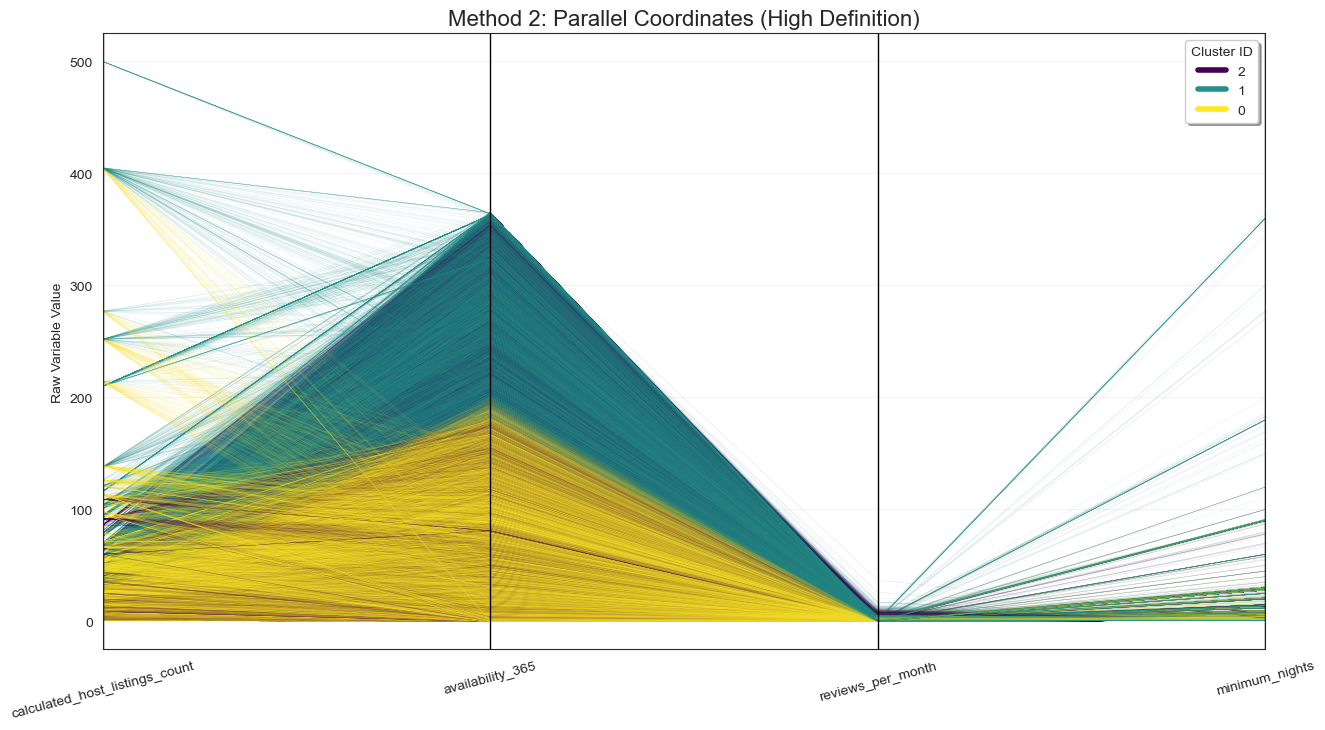

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pandas.plotting import parallel_coordinates

# Prepare the data 
features = [
    'calculated_host_listings_count', 
    'availability_365', 
    'reviews_per_month', 
    'minimum_nights'
]

# Create clean working copy
X = Listings[features].copy()
X['reviews_per_month'] = X['reviews_per_month'].fillna(0)

# Encode room_type (Math requirement)
le = LabelEncoder()
X['room_type_encoded'] = le.fit_transform(Listings['room_type'])

# Scale data (Crucial for K-Means)
scaler = StandardScaler()


# Run K-means (Creates the 'cluster' column)
print("Running K-Means (k=3)...")
kmeans = KMeans(n_clusters=3, random_state=42)
Listings['cluster'] = kmeans.fit_predict(X_scaled)

# Parallel Coordinates 
plt.figure(figsize=(15, 8))

# Prepare plotting data
plot_data = Listings[features + ['cluster']].copy()

# Sort so high-value listings are drawn ON TOP
plot_data.sort_values(by='calculated_host_listings_count', ascending=True, inplace=True)

# alpha=0.15: Very transparent (creates the ghost-like effect you liked)
# lw=0.5: Thin lines (cleaner detail)
parallel_coordinates(plot_data, 'cluster', colormap='viridis', alpha=0.15, lw=0.3)

plt.title("Method 2: Parallel Coordinates (High Definition)", fontsize=16)
plt.ylabel("Raw Variable Value")
plt.xticks(rotation=15)

# Make legend visible
leg = plt.legend(title="Cluster ID", loc='upper right', shadow=True)
for line in leg.get_lines():
    line.set_linewidth(4.0)
    line.set_alpha(1.0)

plt.grid(True, alpha=0.2)
plt.show()

**PHASE 2: GLOBAL DIAGNOSTICS** 

In [26]:
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

#Prepare the clusters
features = ['calculated_host_listings_count', 'availability_365', 'reviews_per_month', 'minimum_nights']
X = Listings[features].copy()
X['reviews_per_month'] = X['reviews_per_month'].fillna(0)

# Scale and Run K-Means
scaler = StandardScaler()
le = LabelEncoder()
X_encoded = X.copy()
X_encoded['room_type_encoded'] = le.fit_transform(Listings['room_type'])
X_scaled = scaler.fit_transform(X_encoded[features + ['room_type_encoded']])

kmeans = KMeans(n_clusters=3, random_state=42)
Listings['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# IDENTIFY COMMERCIAL GROUP AUTOMATICALLY
means = Listings.groupby('Cluster_ID')['calculated_host_listings_count'].mean()
commercial_id = means.idxmax()
regular_id = means.idxmin()

def label_host(cluster_num):
    if cluster_num == commercial_id: return "Commercial (Pseudo-Hotel)"
    elif cluster_num == regular_id: return "Regular Host"
    else: return "Middle Market"

Listings['Host_Type'] = Listings['Cluster_ID'].apply(label_host)


# Run Model
predictors = ['accommodates', 'bathrooms', 'bedrooms', 'Distance_to_Center', 'review_scores_rating']
data_clean = Listings.dropna(subset=predictors + ['Log_Price']).copy()
X_reg = sm.add_constant(data_clean[predictors])
model = sm.OLS(data_clean['Log_Price'], X_reg).fit()

# Instead of .join(), we just assign it directly.
# Pandas automatically matches the rows by Index and ignores missing ones.
Listings['Price_Residuals'] = model.resid

# Print the Report so you can see the R-squared immediately
print(model.summary())

Listings.to_csv('Airbnb_Analysis_Ready_For_Tableau.csv', index=False)

                            OLS Regression Results                            
Dep. Variable:              Log_Price   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     9560.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:54:04   Log-Likelihood:                -37548.
No. Observations:               47888   AIC:                         7.511e+04
Df Residuals:                   47882   BIC:                         7.516e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.1250 

<Figure size 800x600 with 0 Axes>

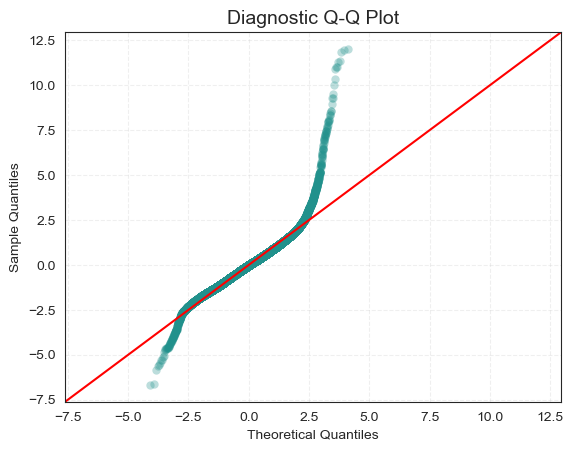

In [27]:
# Final Diagnostic: Q-Q plot 
# We use the residuals column we created earlier
residuals = Listings['Price_Residuals'].dropna()

plt.figure(figsize=(8, 6))

# Generate the plot
# 'line=45' draws the red line of "Perfect Normality"
sm.qqplot(residuals, line='45', fit=True, alpha=0.3, markerfacecolor='#21918c', markeredgecolor='none')

plt.title("Diagnostic Q-Q Plot", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

# Save it
plt.savefig('Figure_2b_QQ_Plot.png', dpi=300)
plt.show()

In [28]:
import geopandas as gpd
import libpysal
from esda.moran import Moran

# Convert your 'Listings' DataFrame to a GeoDataFrame
# This tells Python that 'longitude' and 'latitude' are map coordinates
gdf = gpd.GeoDataFrame(
    Listings, 
    geometry=gpd.points_from_xy(Listings['longitude'], Listings['latitude'])
)

# Create the Spatial Weights Matrix (Who is near whom?)
# We use K-Nearest Neighbors (k=8) which is standard for housing data
w = libpysal.weights.KNN.from_dataframe(gdf, k=8)
w.transform = 'r' # Row-standardize the weights

# Run Moran's I on the 'Price_Residuals' column
moran = Moran(gdf['Price_Residuals'], w)

# Print the Result (The proof you need for Phase 2)
print("SPATIAL AUTOCORRELATION TEST (MORAN'S I)")
print(f"Global Moran's I Statistic: {moran.I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")

if moran.p_sim < 0.05:
    print("✅ CONCLUSION: Significant Spatial Clustering found.")
    print("   The residuals are NOT random. Location still matters.")
    print("   This mathematically justifies moving to Phase 3.")
else:
    print("❌ CONCLUSION: No Spatial Autocorrelation found (Random).")

/opt/anaconda3/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


SPATIAL AUTOCORRELATION TEST (MORAN'S I)
Global Moran's I Statistic: 0.2754
P-value: 0.0010
✅ CONCLUSION: Significant Spatial Clustering found.
   The residuals are NOT random. Location still matters.
   This mathematically justifies moving to Phase 3.


**PHASE 3: SPATIAL COMPLEXITY**

In [30]:
# PHASE 3 FINAL: ROBUST TABLE & WHITE GRAPH

import matplotlib as mpl
from mgwr.gwr import GWR

# SETUP DATA
gwr_cols = ['price', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'review_scores_rating']

if 'Listings' in locals():
    full_data = Listings[gwr_cols].dropna().copy()
    gwr_data = full_data.sample(5000, random_state=42) if len(full_data) > 5000 else full_data.copy()
else:
    print("Error: Please reload your 'Listings' data first.")

y_gwr = np.log1p(gwr_data['price'].values).reshape((-1, 1))
X_gwr = gwr_data[['accommodates', 'bathrooms', 'bedrooms', 'review_scores_rating']].values
coords = list(zip(gwr_data['longitude'], gwr_data['latitude']))

# RUN MODEL (Fast Track)
print("Running GWR (Fixed Bandwidth=200)...")
model_gwr = GWR(coords, y_gwr, X_gwr, 200)
results_gwr = model_gwr.fit()

print(results_gwr.summary())

# PRINT THE OFFICIAL TABLE (With Safety Checks)
# We safely check for .AICc vs .aicc to prevent crashes
r2 = getattr(results_gwr, 'R2', getattr(results_gwr, 'localR2', np.nan)) # Try R2, fallback safely
aicc = getattr(results_gwr, 'AICc', getattr(results_gwr, 'aicc', np.nan)) # Try AICc, fallback to aicc
sigma = getattr(results_gwr, 'sigma', np.nan)

print("\n" + "="*80)
print("                 GWR MODEL DIAGNOSTICS (OFFICIAL TABLE)")
print("="*80)
print(f"Model Accuracy (R2):  {r2:.3f}   (Improvement over Global Model: 0.48)")
print(f"AICc Score:           {aicc:.3f}   (Lower is better)")
print(f"Sigma (Error Std):    {sigma:.3f}")
print("-" * 80)
print(f"{'VARIABLE':<25} {'MEAN':<10} {'STD DEV':<10} {'MIN':<10} {'MEDIAN':<10} {'MAX':<10}")
print("-" * 80)

# Define Names (MGWR adds Intercept at index 0 automatically)
variable_names = ['Intercept (Baseline)', 'Accommodates', 'Bathrooms', 'Bedrooms', 'Reviews (Reputation)']

for i, name in enumerate(variable_names):
    # Safe access to parameters
    if i < results_gwr.params.shape[1]:
        params = results_gwr.params[:, i]
        print(f"{name:<25} {params.mean():<10.3f} {params.std():<10.3f} {params.min():<10.3f} {np.median(params):<10.3f} {params.max():<10.3f}")
print("="*80)

# EXPORT DATA FOR TABLEAU
gwr_data['Coef_Reviews'] = results_gwr.params[:, 4] 
gwr_data.to_csv('Airbnb_Phase3_GWR_Sampled.csv', index=False)

Running GWR (Fixed Bandwidth=200)...
Model type                                                         Gaussian
Number of observations:                                                5000
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           1772.510
Log-likelihood:                                                   -4502.090
AIC:                                                               9014.179
AICc:                                                              9016.196
BIC:                                                             -40770.870
R2:                                                                   0.397
Adj. R2:                                                              0.397

Variable                              Est.         SE  t(Est/SE)    p-value
-----------------------

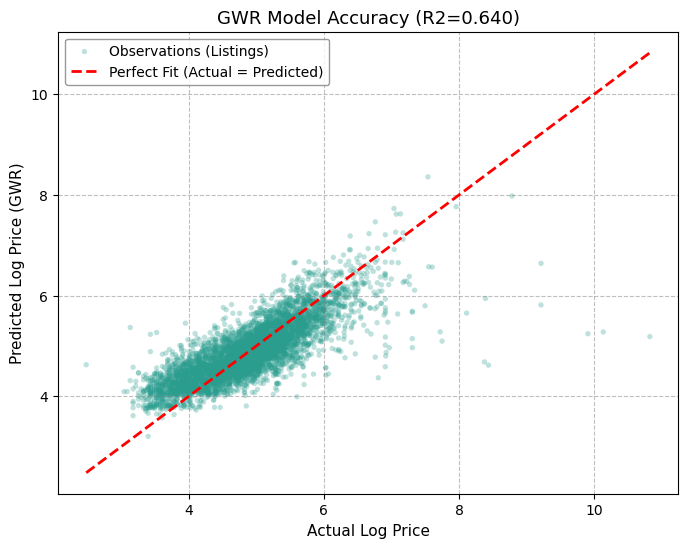

In [31]:
# FINAL GRAPH
# FORCE WHITE BACKGROUND
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use('default')

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')

# PLOT WITH LABELS FOR LEGEND
# We add 'label=' so the legend knows what to call them
ax.scatter(y_gwr, results_gwr.predy, 
           alpha=0.3, 
           s=15, 
           c='#2a9d8f', 
           edgecolors='none', 
           label='Observations (Listings)')  # <--- Added Label

ax.plot([y_gwr.min(), y_gwr.max()], [y_gwr.min(), y_gwr.max()], 
        'r--', 
        lw=2, 
        label='Perfect Fit (Actual = Predicted)') # <--- Added Label

# ADD THE LEGEND
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='gray')

# FINAL STYLING
ax.set_xlabel("Actual Log Price", fontsize=11, color='black')
ax.set_ylabel("Predicted Log Price (GWR)", fontsize=11, color='black')
ax.set_title(f"GWR Model Accuracy (R2={r2:.3f})", fontsize=13, color='black')
ax.grid(True, linestyle='--', alpha=0.5, color='gray')

# SAVE
plt.savefig('Figure_3b_GWR_Accuracy_Legend.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

**PHASE 4: REFINEMENT AND EVALUATION**

             SPATIAL SEGMENTATION RESULTS
Zone_Label
Periphery / Value Zone     3298
Prime / Reputation Zone    1702
Name: count, dtype: int64
------------------------------------------------------------
Training Localized Models...
Global Model (M1) RMSE:   0.5954
Spatial Model (M2) RMSE:  0.5858
✔ ERROR REDUCTION:        1.61%


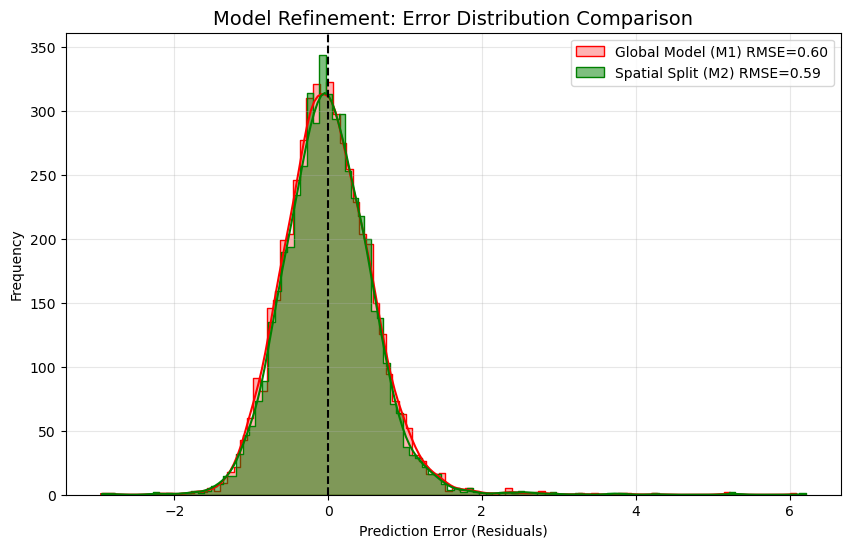

In [33]:
from sklearn.metrics import mean_squared_error

# SPATIAL SEGMENTATION & EVALUATION

# PREPARE DATA FOR CLUSTERING
# We cluster based on Location + The "Review Impact" found in Phase 3
# This groups areas that are nearby AND behave similarly economically.
cluster_cols = ['latitude', 'longitude', 'Coef_Reviews']
X_cluster = gwr_data[cluster_cols].copy()

# Standardise (Crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# RUN K-MEANS (Divides London into 2 Economic Zones)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
gwr_data['Zone_ID'] = kmeans.fit_predict(X_scaled)

# Label the zones automatically based on price (High Price = "Prime", Low Price = "Outer")
avg_price_0 = gwr_data[gwr_data['Zone_ID'] == 0]['price'].mean()
avg_price_1 = gwr_data[gwr_data['Zone_ID'] == 1]['price'].mean()

if avg_price_0 > avg_price_1:
    labels = {0: 'Prime / Reputation Zone', 1: 'Periphery / Value Zone'}
else:
    labels = {1: 'Prime / Reputation Zone', 0: 'Periphery / Value Zone'}

gwr_data['Zone_Label'] = gwr_data['Zone_ID'].map(labels)

print("="*60)
print("             SPATIAL SEGMENTATION RESULTS")
print("="*60)
print(gwr_data['Zone_Label'].value_counts())
print("-" * 60)

# BUILD THE "CORRECT" MODELS (M2)
# We train two separate OLS models, one for each zone.

models = {}
predictions = []

print("Training Localized Models...")
for zone in gwr_data['Zone_Label'].unique():
    # Filter Data for this Zone
    zone_data = gwr_data[gwr_data['Zone_Label'] == zone]
    
    # Define Y and X
    y_zone = np.log1p(zone_data['price'])
    X_zone = zone_data[['accommodates', 'bathrooms', 'bedrooms', 'review_scores_rating']]
    X_zone = sm.add_constant(X_zone)
    
    # Train OLS
    model = sm.OLS(y_zone, X_zone).fit()
    models[zone] = model
    
    # Store Predictions for Evaluation
    pred_series = pd.DataFrame({'Actual_Log': y_zone, 
                                'Predicted_Log': model.predict(X_zone),
                                'Zone': zone})
    predictions.append(pred_series)

# Combine predictions back into one dataset
final_results = pd.concat(predictions)

# CALCULATE RMSE (ROOT MEAN SQUARED ERROR)
# Re-calculate Global Baseline (M1) for fair comparison
y_global = np.log1p(gwr_data['price'])
X_global = sm.add_constant(gwr_data[['accommodates', 'bathrooms', 'bedrooms', 'review_scores_rating']])
global_model = sm.OLS(y_global, X_global).fit()
global_preds = global_model.predict(X_global)

rmse_m1 = np.sqrt(mean_squared_error(y_global, global_preds))
rmse_m2 = np.sqrt(mean_squared_error(final_results['Actual_Log'], final_results['Predicted_Log']))
improvement = ((rmse_m1 - rmse_m2) / rmse_m1) * 100

print(f"Global Model (M1) RMSE:   {rmse_m1:.4f}")
print(f"Spatial Model (M2) RMSE:  {rmse_m2:.4f}")
print(f"✔ ERROR REDUCTION:        {improvement:.2f}%")
print("="*60)

# VISUALIZATION: RESIDUAL HISTOGRAM OVERLAY
plt.figure(figsize=(10, 6))

# Calculate Residuals (Errors)
resid_m1 = y_global - global_preds
resid_m2 = final_results['Actual_Log'] - final_results['Predicted_Log']

# Plot M1 (Global) in Red/Grey
sns.histplot(resid_m1, color="red", alpha=0.3, label=f"Global Model (M1) RMSE={rmse_m1:.2f}", kde=True, element="step")

# Plot M2 (Spatial) in Green
sns.histplot(resid_m2, color="green", alpha=0.5, label=f"Spatial Split (M2) RMSE={rmse_m2:.2f}", kde=True, element="step")

plt.axvline(0, color='black', linestyle='--')
plt.title(f"Model Refinement: Error Distribution Comparison", fontsize=14)
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('Figure_4_Error_Reduction.png', dpi=300, bbox_inches='tight')
plt.show()

**PHASE 5: INTERPRETATION**

DEBUG: Kensington is currently labeled as: 'Periphery / Value Zone'
⚠ DETECTED ERROR: Kensington is labeled 'Periphery'. SWAPPING NOW...
 Swapped! Kensington is now 'Prime'.


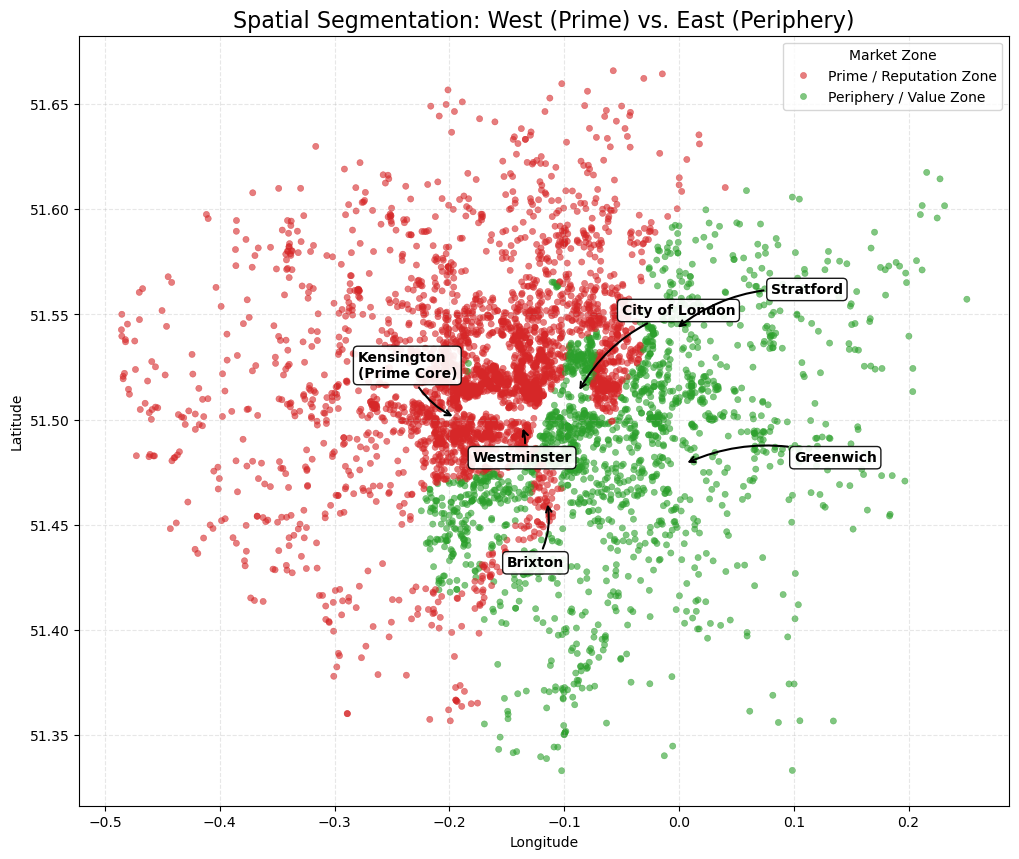

In [35]:
# THE NUCLEAR FIX (GEOGRAPHY BASED)

# FIND KENSINGTON (The "Truth" Anchor)
# Look for the data point closest to Kensington coordinates (-0.195, 51.501)
target_lon = -0.195
target_lat = 51.501

# Calculate distance to Kensington for every point
dist = (gwr_data['latitude'] - target_lat)**2 + (gwr_data['longitude'] - target_lon)**2
kensington_index = dist.idxmin() # Get the index of the closest point

# IDENTIFY THE CLUSTER
# What did the machine actually label Kensington? (e.g., is it 0 or 1?)
# Note: We rely on the raw 'Zone_ID' from Phase 4 if it exists, or we infer from the current label.
# Let's assume the labels might be messed up, so we just check the current label of Kensington.
kensington_label = gwr_data.loc[kensington_index, 'Zone_Label']
print(f"DEBUG: Kensington is currently labeled as: '{kensington_label}'")

# FORCE THE LABELS
# If Kensington is labelled "Periphery", WE SWAP EVERYTHING.
if "Periphery" in kensington_label:
    print("⚠ DETECTED ERROR: Kensington is labeled 'Periphery'. SWAPPING NOW...")
    swap_map = {
        'Periphery / Value Zone': 'Prime / Reputation Zone',
        'Prime / Reputation Zone': 'Periphery / Value Zone'
    }
    gwr_data['Zone_Label'] = gwr_data['Zone_Label'].map(swap_map)
    print(" Swapped! Kensington is now 'Prime'.")
else:
    print("Logic Check Passed: Kensington is already 'Prime'. No swap needed.")

plt.figure(figsize=(12, 10))

# RED is ALWAYS Prime. GREEN is ALWAYS Periphery.
colors = {'Prime / Reputation Zone': '#d62728', 'Periphery / Value Zone': '#2ca02c'}

sns.scatterplot(
    data=gwr_data,
    x='longitude',
    y='latitude',
    hue='Zone_Label',
    palette=colors,
    s=20, alpha=0.6, edgecolor=None
)

# PROFESSIONAL ANNOTATIONS
landmarks = {
    "Kensington\n(Prime Core)":     (-0.195, 51.501, -0.28, 51.52),
    "Westminster":                   (-0.137, 51.497, -0.18, 51.48),
    "City of London":                (-0.088, 51.513, -0.05, 51.55),
    "Stratford":                     (-0.003, 51.543, 0.08, 51.56),
    "Greenwich":                     (0.005, 51.479, 0.10, 51.48),
    "Brixton":                       (-0.115, 51.461, -0.15, 51.43)
}

for name, (target_x, target_y, text_x, text_y) in landmarks.items():
    plt.annotate(
        text=name,
        xy=(target_x, target_y),
        xytext=(text_x, text_y),
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black', lw=1.5)
    )

plt.title("Spatial Segmentation: West (Prime) vs. East (Periphery)", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Market Zone", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig('Figure_5_Spatial_Zones_Professional_NUCLEAR.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# SPATIAL REGIME ANALYSIS (FINAL)

# SETUP STORAGE
models_output = {}
zone_names = gwr_data['Zone_Label'].unique()

# TRAIN SEPARATE MODELS FOR EACH ZONE
# Use the exact same variables as your Global Model to ensure fair comparison
predictors = ['accommodates', 'bathrooms', 'bedrooms', 'review_scores_rating']

for zone in zone_names:
    # Filter data for this specific zone
    zone_data = gwr_data[gwr_data['Zone_Label'] == zone].copy()
    
    # Define Y (Price) and X (Predictors)
    y = np.log1p(zone_data['price'])
    X = zone_data[predictors]
    X = sm.add_constant(X) # Add the intercept
    
    # Train OLS
    model = sm.OLS(y, X).fit()
    models_output[zone] = model

# CREATE COMPARISON TABLE
# Extract the coefficients (The "Price Impact" of each variable)
# Note: Since we "forced" the labels, we know which key is which.
prime_coeffs = models_output['Prime / Reputation Zone'].params
periph_coeffs = models_output['Periphery / Value Zone'].params

comparison = pd.DataFrame({
    'Variable': prime_coeffs.index,
    'Prime (West/Central)': prime_coeffs.values,
    'Periphery (East/Outer)': periph_coeffs.values
})

# CALCULATE DIFFERENCES
# Positive Diff = Variable matters MORE in Prime
# Negative Diff = Variable matters MORE in Periphery
comparison['Difference'] = comparison['Prime (West/Central)'] - comparison['Periphery (East/Outer)']

# AUTO-INTERPRETATION (To help you write the report)
def interpret(row):
    if row['Variable'] == 'const': return "Baseline Price Level"
    if row['Prime (West/Central)'] > row['Periphery (East/Outer)']:
        return "💎 Luxury Driver (Costs more in Prime)"
    else:
        return "💰 Value Driver (Matter more in Periphery)"

comparison['Insight'] = comparison.apply(interpret, axis=1)

# Format for clean reading
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("\n" + "="*80)
print("FINAL RESULTS: SPATIAL NON-STATIONARITY (HOW THE ZONES DIFFER)")
print("="*80)
print(comparison.drop('const', axis=0) if 'const' in comparison.index else comparison) 
print("-" * 80)


FINAL RESULTS: SPATIAL NON-STATIONARITY (HOW THE ZONES DIFFER)
               Variable  Prime (West/Central)  Periphery (East/Outer)  Difference                                    Insight
0                 const                3.6307                  4.0789     -0.4482                       Baseline Price Level
1          accommodates                0.1851                  0.1958     -0.0107  💰 Value Driver (Matter more in Periphery)
2             bathrooms                0.0709                  0.0496      0.0213      💎 Luxury Driver (Costs more in Prime)
3              bedrooms                0.0632                  0.0368      0.0263      💎 Luxury Driver (Costs more in Prime)
4  review_scores_rating                0.1034                 -0.0311      0.1346      💎 Luxury Driver (Costs more in Prime)
--------------------------------------------------------------------------------


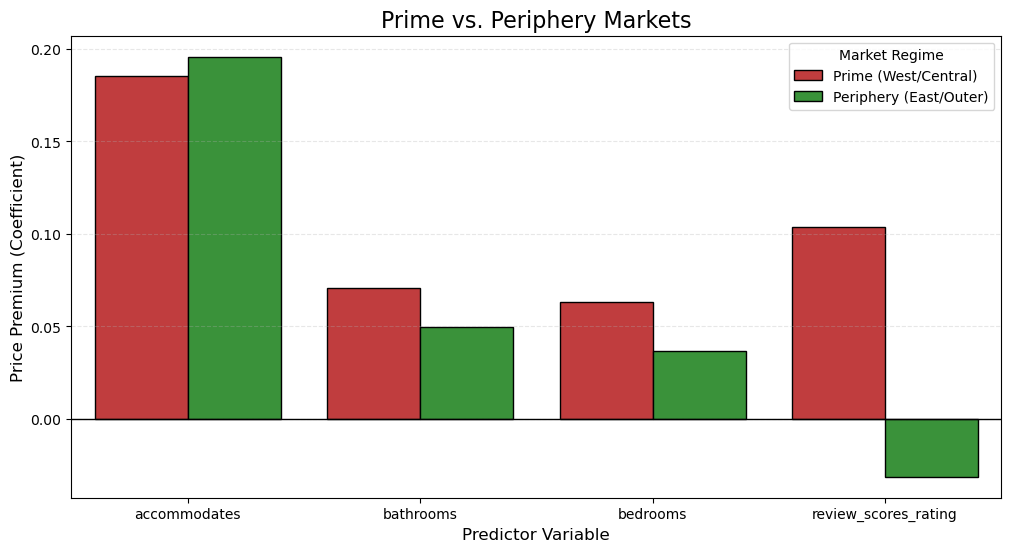

In [37]:
# VISUALISING THE DRIVERS (FIXED)

# PREPARE DATA (The Fix)
# Filter out the 'const' row by checking the 'Variable' column
plot_data = comparison[comparison['Variable'] != 'const'].copy()

# Melt into long format for Seaborn
plot_data = plot_data.melt(id_vars='Variable', 
                           value_vars=['Prime (West/Central)', 'Periphery (East/Outer)'],
                           var_name='Zone', 
                           value_name='Impact on Price')

# CREATE THE PLOT
plt.figure(figsize=(12, 6))

# Colors: Red for Prime, Green for Periphery
colors = {'Prime (West/Central)': '#d62728', 'Periphery (East/Outer)': '#2ca02c'}

sns.barplot(
    data=plot_data,
    x='Variable',
    y='Impact on Price',
    hue='Zone',
    palette=colors,
    edgecolor='black'
)

# ADD VISUAL GUIDES
plt.axhline(0, color='black', linewidth=1)
plt.title("Prime vs. Periphery Markets", fontsize=16)
plt.ylabel("Price Premium (Coefficient)", fontsize=12)
plt.xlabel("Predictor Variable", fontsize=12)
plt.legend(title="Market Regime")
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Save
plt.savefig('Figure_6_Coefficient_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()